## 长度分布可视化

ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: .16477022236
ERROR:root:Unsupported cell attribute type: -0.74197758445 for file: D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen\00000802.nii_R_ICA_labeled.vtk
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: -nan(ind)
ERROR:root:Unsupported cell attribute type: 6.9770608134e-18 for file: D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen\00001454.nii_R_ICA_labeled.vtk
ERROR:root:Unsupported data type: 
ERROR:root:Unsupported data type: .27630379481
ERROR:root:Unsupported cell attribute type: 0.86895944355 for file: D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen\00001612.nii_R_ICA_labeled.vtk
ERROR:root:Unsup

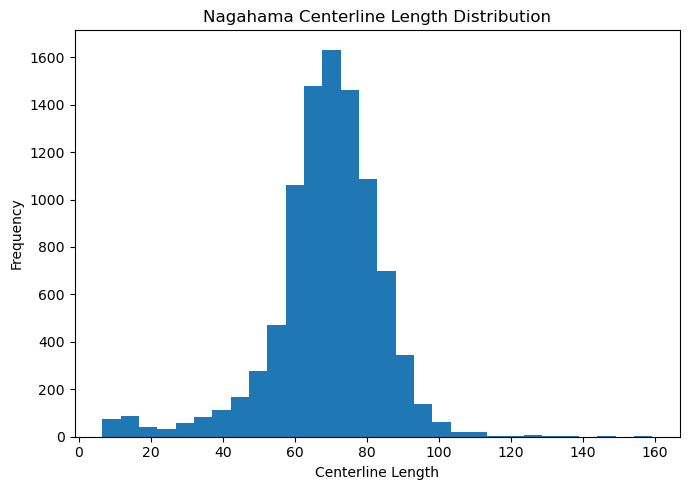

In [5]:
import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

root_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen"

lengths = []

def compute_centerline_length(poly):
    """
    按 connectivity 顺序计算中心线弧长
    """
    lines = poly.lines
    if lines.size == 0:
        return np.nan

    n_pts = lines[0]
    ids = lines[1:n_pts + 1]
    pts = poly.points[ids]

    return np.linalg.norm(np.diff(pts, axis=0), axis=1).sum()

for fname in os.listdir(root_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    poly = pv.read(os.path.join(root_dir, fname))
    length = compute_centerline_length(poly)

    if not np.isnan(length):
        lengths.append(length)

# ===== 画分布图 =====
plt.figure(figsize=(7, 5))
plt.hist(lengths, bins=30)
plt.xlabel("Centerline Length")
plt.ylabel("Frequency")
plt.title("Nagahama Centerline Length Distribution")
plt.tight_layout()
plt.show()


## 去除短的中心线（60以下）

In [16]:
import os
import numpy as np
import pyvista as pv
import logging
import shutil

# ===== 关闭 VTK / PyVista 的刷屏日志 =====
logging.getLogger().setLevel(logging.CRITICAL)

# ===== 路径 =====
src_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\1_from chen"
dst_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\2_centerline_60"

os.makedirs(dst_dir, exist_ok=True)

def compute_centerline_length(poly):
    """
    按 LINES connectivity 计算中心线真实弧长
    （只用于筛选，不改变任何数据）
    """
    lines = poly.lines
    if lines.size == 0:
        return np.nan

    n_pts = int(lines[0])
    ids = lines[1:n_pts + 1]
    pts = poly.points[ids]

    return np.linalg.norm(np.diff(pts, axis=0), axis=1).sum()

# ===== 统计量 =====
total = 0
kept = 0
removed = 0

for fname in os.listdir(src_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    total += 1
    src_path = os.path.join(src_dir, fname)

    try:
        poly = pv.read(src_path)

        # 基本合法性检查
        if poly.GetClassName() != "vtkPolyData" or poly.lines.size == 0:
            removed += 1
            continue

        length = compute_centerline_length(poly)

        # 长度筛选（≥ 60）
        if np.isnan(length) or length < 60.0:
            removed += 1
            continue

        # ===== 关键点：原样复制，不重新写 =====
        shutil.copy2(src_path, os.path.join(dst_dir, fname))
        kept += 1

    except Exception:
        removed += 1
        continue

# ===== 打印结果 =====
print("===== Centerline count summary =====")
print(f"Total centerlines (before): {total}")
print(f"Kept (length ≥ 60):         {kept}")
print(f"Removed:                   {removed}")


===== Centerline count summary =====
Total centerlines (before): 9432
Kept (length ≥ 60):         7559
Removed:                   1873


## 改成txt（间隔0.3）

In [64]:
import os
import numpy as np
import pyvista as pv
import logging

# ===== 关闭刷屏日志 =====
logging.getLogger().setLevel(logging.CRITICAL)

# ===== 输入 / 输出目录 =====
#src_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\2_centerline_60"
#dst_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\3_centerline_60_txt"

src_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt"
dst_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out"


os.makedirs(dst_dir, exist_ok=True)

SPACING = 0.5  # 目标点间距（单位与坐标一致）

def extract_ordered_points(poly):
    """按 LINES connectivity 提取有序中心线点"""
    lines = poly.lines
    n_pts = int(lines[0])
    ids = lines[1:n_pts + 1].astype(int)
    return poly.points[ids]

def resample_by_arclength(pts, ds):
    """
    沿真实弧长以固定间距 ds 重采样
    返回：重采样后的点 (N,3)
    """
    # 原始弧长
    s = np.zeros(len(pts))
    s[1:] = np.cumsum(np.linalg.norm(np.diff(pts, axis=0), axis=1))

    total_len = s[-1]
    if total_len <= ds:
        return pts.copy()

    s_new = np.arange(0.0, total_len + 1e-8, ds)

    x_new = np.interp(s_new, s, pts[:, 0])
    y_new = np.interp(s_new, s, pts[:, 1])
    z_new = np.interp(s_new, s, pts[:, 2])

    return np.column_stack([x_new, y_new, z_new])

def export_txt(points, txt_path):
    with open(txt_path, "w") as f:
        f.write(f"#spline3d {len(points)}\n")
        for x, y, z in points:
            f.write(f"{x:.8f} {y:.8f} {z:.8f}\n")

# ===== 主循环 =====
count = 0

for fname in os.listdir(src_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    vtk_path = os.path.join(src_dir, fname)

    try:
        poly = pv.read(vtk_path)
        if poly.GetClassName() != "vtkPolyData" or poly.lines.size == 0:
            continue

        # 1. 提取中心线顺序点
        pts = extract_ordered_points(poly)

        # 2. 按 0.3 重采样
        pts_resampled = resample_by_arclength(pts, SPACING)

        # 3. 导出 txt
        txt_name = os.path.splitext(fname)[0] + ".txt"
        txt_path = os.path.join(dst_dir, txt_name)
        export_txt(pts_resampled, txt_path)

        count += 1

    except Exception:
        continue

print(f"Exported txt files: {count}")


Exported txt files: 16


## 计算曲率

In [65]:
import os
import subprocess

# === 路径设置 ===
#input_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\3_centerline_60_txt"
input_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out"
exe_path = r"D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\batchVModeler.exe"
param_file = r"D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\param_5d_L3.txt"
output_root = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out_curvature"

# === 固定参数 ===
mode_number = "1030"
flag1 = "1"
flag2 = "1"
flag3 = "1"
scale = "1.0"

# === 遍历每个 txt 文件 ===
for fn in os.listdir(input_dir):
    if not fn.endswith(".txt"):
        continue

    input_file = os.path.join(input_dir, fn)
    base_name = os.path.splitext(fn)[0]  # 去掉后缀
    out_dir = os.path.join(output_root, base_name)
    os.makedirs(out_dir, exist_ok=True)

    # 拼接命令
    cmd = [
        exe_path,
        mode_number,
        input_file,
        param_file,
        flag1, flag2, flag3,
        out_dir + "\\",  # 确保结尾有反斜杠
        scale
    ]

    print("正在运行：", " ".join(cmd))
    # 执行命令
    subprocess.run(cmd)

print("全部文件已处理完成。")


正在运行： D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\batchVModeler.exe 1030 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out\00000000.nii_L_ICA_labeled.txt D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\param_5d_L3.txt 1 1 1 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out_curvature\00000000.nii_L_ICA_labeled\ 1.0


正在运行： D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\batchVModeler.exe 1030 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out\00000000.nii_R_ICA_labeled.txt D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\param_5d_L3.txt 1 1 1 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out_curvature\00000000.nii_R_ICA_labeled\ 1.0
正在运行： D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\batchVModeler.exe 1030 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out\00000001.nii_L_ICA_labeled.txt D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\param_5d_L3.txt 1 1 1 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out_curvature\00000001.nii_L_ICA_labeled\ 1.0
正在运行： D:\github\Phd_summary\2_Code\1_Brava\1_Preprocessing\curvature\code\curvature\batchVModeler.exe 1030 D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\test_txt_out\000

In [19]:
import os
import shutil

# ===== 根目录 =====
root_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\4_centerline_60_curvature"

# ===== 统一输出目录 =====
save_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\5_centerline_60_curvature_vals"
os.makedirs(save_dir, exist_ok=True)

count = 0

# ===== 遍历所有 labeled 子文件夹 =====
for labeled_folder in os.listdir(root_dir):
    labeled_path = os.path.join(root_dir, labeled_folder)

    if not os.path.isdir(labeled_path):
        continue
    if not labeled_folder.endswith("labeled"):
        continue

    # ===== 找 _sigma0 子文件夹 =====
    for sub in os.listdir(labeled_path):
        if "_sigma0" not in sub:
            continue

        sigma0_path = os.path.join(labeled_path, sub)
        if not os.path.isdir(sigma0_path):
            continue

        # ===== 目标文件：_vals.txt =====
        src_file = os.path.join(sigma0_path, "_vals.txt")
        if not os.path.isfile(src_file):
            continue

        # ===== 输出文件名：labeled 文件夹名 =====
        dst_name = labeled_folder + ".txt"
        dst_file = os.path.join(save_dir, dst_name)

        shutil.copy2(src_file, dst_file)
        count += 1

print(f"✅ 共复制 {count} 个 _vals.txt 文件到：\n{save_dir}")


✅ 共复制 7559 个 _vals.txt 文件到：
D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\5_centerline_60_curvature_vals


In [41]:
import os
import numpy as np

# =========================================================
# 路径
# =========================================================
input_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\5_centerline_60_curvature_vals"
output_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\6_centerline_60_vtk_final"

TARGET_DS = 0.3  # 固定点间距
os.makedirs(output_dir, exist_ok=True)

# =========================================================
# 读取 _vals.txt
# 需要列：s, x, y, z, curvature, torsion
# =========================================================
def load_vals_txt(txt_path):
    with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    header = lines[0].lstrip("#").split()
    idx = {name: i for i, name in enumerate(header)}

    required = ["s", "x", "y", "z", "curvature", "torsion"]
    missing = [k for k in required if k not in idx]
    if missing:
        raise ValueError(f"Missing columns {missing} in {txt_path}")

    s, pts, curv, tors = [], [], [], []

    for ln in lines[1:]:
        p = ln.split()
        s.append(float(p[idx["s"]]))
        pts.append([
            float(p[idx["x"]]),
            float(p[idx["y"]]),
            float(p[idx["z"]]),
        ])
        curv.append(float(p[idx["curvature"]]))
        tors.append(float(p[idx["torsion"]]))

    return (
        np.asarray(s),
        np.asarray(pts),
        np.asarray(curv),
        np.asarray(tors),
    )

# =========================================================
# 手写 VTK（1 行 1 点，完全对齐 BG0001_ICA_L.vtk）
# =========================================================
def write_vtk_bg_style(
    vtk_path,
    points,
    curvature,
    torsion,
    title="Centerline"
):
    n = len(points)
    if n < 2:
        raise ValueError("Need at least 2 points")

    with open(vtk_path, "w", encoding="utf-8") as f:
        f.write("# vtk DataFile Version 2.0\n")
        f.write(f"{title}\n")
        f.write("ASCII\n")
        f.write("DATASET POLYDATA\n")

        # ---- POINTS: 一行一个点 ----
        f.write(f"POINTS {n} float\n")
        for x, y, z in points:
            f.write(f"{x} {y} {z}\n")

        # ---- LINES: 单条 polyline ----
        f.write(f"LINES 1 {n + 1}\n")
        f.write(str(n) + " " + " ".join(map(str, range(n))) + "\n\n")

        # ---- POINT_DATA ----
        f.write(f"POINT_DATA {n}\n")

        f.write("SCALARS curvature float\n")
        f.write("LOOKUP_TABLE default\n")
        for v in curvature:
            f.write(f"{v}\n")

        f.write("SCALARS torsion float\n")
        f.write("LOOKUP_TABLE default\n")
        for v in torsion:
            f.write(f"{v}\n")

# =========================================================
# 主处理流程（重采样 + 翻转 + 写 VTK）
# =========================================================
total = ok = bad = 0

for fn in os.listdir(input_dir):
    if not fn.lower().endswith(".txt"):
        continue

    total += 1
    in_path = os.path.join(input_dir, fn)
    out_path = os.path.join(
        output_dir,
        os.path.splitext(fn)[0] + "_resampled0.3.vtk"
    )

    try:
        s, pts, curv, tors = load_vals_txt(in_path)

        if len(s) < 2:
            bad += 1
            continue

        # ---- 重采样 ----
        s_new = np.arange(s[0], s[-1] + 1e-8, TARGET_DS)

        x_new = np.interp(s_new, s, pts[:, 0])
        y_new = np.interp(s_new, s, pts[:, 1])
        z_new = np.interp(s_new, s, pts[:, 2])
        curv_new = np.interp(s_new, s, curv)
        tors_new = np.interp(s_new, s, tors)

        pts_new = np.column_stack([x_new, y_new, z_new])

        # ---- 翻转顺序 ----
        pts_new = pts_new[::-1]
        curv_new = curv_new[::-1]
        tors_new = tors_new[::-1]

        # ---- 写 VTK ----
        write_vtk_bg_style(
            out_path,
            pts_new,
            curv_new,
            tors_new,
            title=os.path.splitext(fn)[0]
        )

        ok += 1

    except Exception as e:
        print(f"[ERROR] {fn}: {e}")
        bad += 1

print("===== Finished =====")
print(f"Total : {total}")
print(f"OK    : {ok}")
print(f"Bad   : {bad}")
print(f"Out   : {output_dir}")


===== Finished =====
Total : 7559
OK    : 7559
Bad   : 0
Out   : D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\6_centerline_60_vtk_final


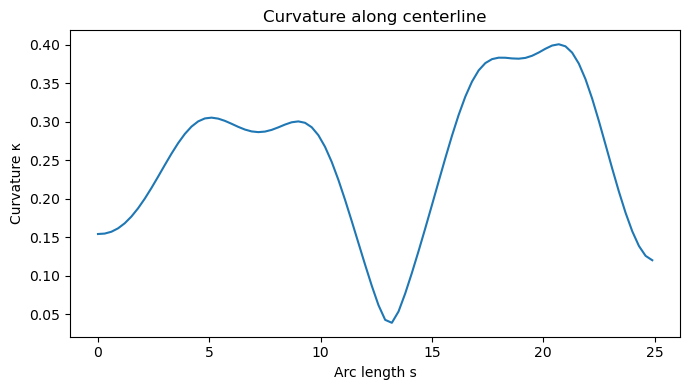

In [49]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

# ===== VTK 路径 =====
vtk_path = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\8_siphon_with_label\00000000.nii_L_ICA_labeled_resampled0.3_siphon_lab.vtk"

# ===== 读取 VTK =====
mesh = pv.read(vtk_path)

# ===== 提取点和曲率 =====
pts = mesh.points                 # (N, 3)
curv = mesh.point_data["curvature"]

# ===== 计算弧长 s =====
ds = np.linalg.norm(np.diff(pts, axis=0), axis=1)
s = np.zeros(len(pts))
s[1:] = np.cumsum(ds)

# ===== 画图 =====
plt.figure(figsize=(7, 4))
plt.plot(s, curv, linewidth=1.5)
plt.xlabel("Arc length s")
plt.ylabel("Curvature κ")
plt.title("Curvature along centerline")
plt.tight_layout()
plt.show()


In [44]:
import os
import numpy as np
import pyvista as pv
from scipy.signal import find_peaks

# =========================================================
# 读取 Nagahama final VTK：points + curvature + torsion + s + s_norm
# =========================================================
def load_centerline_arrays(vtk_path):
    poly = pv.read(vtk_path)

    points = np.asarray(poly.points, dtype=float)
    if "curvature" not in poly.point_data or "torsion" not in poly.point_data:
        raise RuntimeError(f"Missing curvature/torsion in: {vtk_path}")

    curv = np.asarray(poly.point_data["curvature"], dtype=float)
    tors = np.asarray(poly.point_data["torsion"], dtype=float)

    # 基础检查：输入点是否已经坏了
    if not np.isfinite(points).all():
        raise RuntimeError(f"Input VTK points contain NaN/Inf: {vtk_path}")

    # 弧长
    seg = np.linalg.norm(np.diff(points, axis=0), axis=1)
    s = np.insert(np.cumsum(seg), 0, 0.0)
    if s[-1] <= 0:
        raise RuntimeError(f"Invalid length (s[-1]<=0): {vtk_path}")
    s_norm = s / s[-1]

    return points, curv, tors, s, s_norm

# =========================================================
# 你的三条线定义（返回“落到点上的 index”）
# =========================================================
def pick_siphon_indices(points, curv, s_norm):
    peaks, _ = find_peaks(curv)
    if len(peaks) < 2:
        return None
    peaks = np.asarray(peaks, dtype=int)

    # 1) 第一个峰：0.25–0.35 内最大峰
    p1_cand = peaks[(s_norm[peaks] >= 0.25) & (s_norm[peaks] <= 0.35)]
    if len(p1_cand) == 0:
        return None
    p1 = p1_cand[np.argmax(curv[p1_cand])]

    # 2) 第二个峰：0.35–0.5 内最大峰
    p2_cand = peaks[(s_norm[peaks] >= 0.35) & (s_norm[peaks] <= 0.5)]
    if len(p2_cand) == 0:
        return None
    p2 = p2_cand[np.argmax(curv[p2_cand])]

    if p2 <= p1:
        return None

    # 3) 红线：从 p1 向左直到不再下降（落点 index）
    i = p1
    while i > 1 and curv[i - 1] < curv[i]:
        i -= 1
    red = i

    # 4) 黑线：p1 与 p2 之间最低点（落点 index）
    start, end = p1, p2
    black = start + int(np.argmin(curv[start:end + 1]))

    # 5) 黄线：从 p2 向右直到不再下降（落点 index）
    i = p2
    while i < len(curv) - 2 and curv[i + 1] < curv[i]:
        i += 1
    yellow = i

    if not (red < black < yellow):
        return None

    return red, yellow, p1, p2, black  # 你需要的话也能记录

# =========================================================
# 写出 VTK（保持你 final 风格：1行1点 + 1条 polyline + point_data）
# =========================================================
def write_vtk_polyline_ascii(out_path, points, curvature, torsion, title="Siphon segment"):
    n = len(points)
    if n < 2:
        raise RuntimeError("Too few points to write polyline.")

    # 输出前强检查：防止写出 nan nan nan
    if not np.isfinite(points).all():
        raise RuntimeError(f"About to write NaN points: {out_path}")

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("# vtk DataFile Version 2.0\n")
        f.write(f"{title}\n")
        f.write("ASCII\n")
        f.write("DATASET POLYDATA\n")

        f.write(f"POINTS {n} float\n")
        for x, y, z in points:
            f.write(f"{x} {y} {z}\n")

        f.write(f"LINES 1 {n + 1}\n")
        f.write(str(n) + " " + " ".join(map(str, range(n))) + "\n\n")

        f.write(f"POINT_DATA {n}\n")

        f.write("SCALARS curvature float\n")
        f.write("LOOKUP_TABLE default\n")
        for v in curvature:
            f.write(f"{v}\n")

        f.write("SCALARS torsion float\n")
        f.write("LOOKUP_TABLE default\n")
        for v in torsion:
            f.write(f"{v}\n")

# =========================================================
# 主程序（批量）
# =========================================================
if __name__ == "__main__":
    input_dir  = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\6_centerline_60_vtk_final"
    output_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\7_siphon"
    os.makedirs(output_dir, exist_ok=True)

    vtk_files = [
        os.path.join(input_dir, f)
        for f in os.listdir(input_dir)
        if f.lower().endswith(".vtk")
    ]

    kept = 0
    skipped = 0

    for vtk_path in vtk_files:
        try:
            points, curv, tors, s, s_norm = load_centerline_arrays(vtk_path)

            idxs = pick_siphon_indices(points, curv, s_norm)
            if idxs is None:
                skipped += 1
                continue

            red, yellow, p1, p2, black = idxs

            # ===== 这里就是你说的“线要落到点上才能切” =====
            # red/yellow 就是落点 index，直接用来切数组
            pts_cut  = points[red:yellow + 1]
            curv_cut = curv[red:yellow + 1]
            tors_cut = tors[red:yellow + 1]

            out_name = os.path.splitext(os.path.basename(vtk_path))[0] + "_siphon.vtk"
            out_path = os.path.join(output_dir, out_name)

            write_vtk_polyline_ascii(out_path, pts_cut, curv_cut, tors_cut)
            kept += 1

        except Exception as e:
            # 这行非常关键：如果输入本身就有 NaN，会在这里直接告诉你是哪条病例
            print(f"[SKIP] {os.path.basename(vtk_path)} -> {e}")
            skipped += 1

    print("===== Siphon extraction finished =====")
    print(f"Kept   : {kept}")
    print(f"Skipped: {skipped}")
    print(f"Output : {output_dir}")


===== Siphon extraction finished =====
Kept   : 4657
Skipped: 2902
Output : D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\7_siphon


In [66]:
import os
import numpy as np
import pandas as pd
import pyvista as pv

# =========================================================
# 路径
# =========================================================
input_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\7_siphon"
output_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\8_siphon_with_label"
output_excel = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\1_siphon_bend_information_midmin.xlsx"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.dirname(output_excel), exist_ok=True)

# =========================================================
# 参数：中间窗口大小（占总点数比例）
# 例如 0.40 表示取中间 40% 的点来找 valley
# =========================================================
MID_WINDOW_RATIO = 0.7

# =========================================================
# 工具
# =========================================================
def seg_length(pts):
    if len(pts) < 2:
        return None
    return float(np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1)))

def get_curvature(centerline):
    if "curvature" in centerline.point_data:
        return np.asarray(centerline.point_data["curvature"], dtype=float), "curvature"
    if "Curvature" in centerline.point_data:
        return np.asarray(centerline.point_data["Curvature"], dtype=float), "Curvature"
    return None, None

# =========================================================
# 主循环
# =========================================================
results = []
skipped = 0

for fname in os.listdir(input_dir):
    if not fname.lower().endswith(".vtk"):
        continue

    in_path = os.path.join(input_dir, fname)
    model_name = os.path.splitext(fname)[0]
    out_vtk = os.path.join(output_dir, model_name + "_lab.vtk")

    try:
        cl = pv.read(in_path)
        points = np.asarray(cl.points, dtype=float)

        if len(points) < 5:
            skipped += 1
            continue
        if not np.isfinite(points).all():
            skipped += 1
            continue

        curvature, curv_key = get_curvature(cl)
        if curvature is None or len(curvature) != len(points):
            skipped += 1
            continue
        if not np.isfinite(curvature).all():
            skipped += 1
            continue

        n = len(curvature)

        # ========== 中间窗口 ==========
        mid = n // 2
        half_w = int((MID_WINDOW_RATIO * n) / 2)
        half_w = max(2, half_w)

        l = max(0, mid - half_w)
        r = min(n - 1, mid + half_w)

        # ========== valley：窗口内最小曲率点 ==========
        valley = int(l + np.argmin(curvature[l:r + 1]))

        # ========== 标签 ==========
        lab = np.zeros(n, dtype=np.int32)
        lab[:valley] = 1
        lab[valley] = 0
        lab[valley + 1:] = 2

        cl.point_data["lab"] = lab
        cl.save(out_vtk)

        # ========== 统计 ==========
        idx1 = np.where(lab == 1)[0]
        idx2 = np.where(lab == 2)[0]

        b1_len = seg_length(points[idx1]) if len(idx1) >= 2 else None
        b2_len = seg_length(points[idx2]) if len(idx2) >= 2 else None

        b1_max = float(np.max(curvature[idx1])) if len(idx1) > 0 else None
        b2_max = float(np.max(curvature[idx2])) if len(idx2) > 0 else None

        results.append({
            "ModelName": model_name,
            "N_points": n,
            "Mid_window_L": l,
            "Mid_window_R": r,
            "Valley_Index": valley,
            "Valley_Curvature": float(curvature[valley]),
            "Bend1_Length(mm)": b1_len,
            "Bend1_MaxCurvature(1/mm)": b1_max,
            "Bend2_Length(mm)": b2_len,
            "Bend2_MaxCurvature(1/mm)": b2_max,
        })

    except Exception:
        skipped += 1
        continue

# =========================================================
# 输出 Excel
# =========================================================
pd.DataFrame(results).to_excel(output_excel, index=False, engine="openpyxl")

print("✅ Done")
print(f"Output vtk dir : {output_dir}")
print(f"Excel          : {output_excel}")
print(f"Skipped        : {skipped}")


✅ Done
Output vtk dir : D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\8_siphon_with_label
Excel          : D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\1_siphon_bend_information_midmin.xlsx
Skipped        : 0


In [67]:
import pandas as pd

# ===== 原始 Excel 路径 =====
input_excel = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop.xlsx"

# ===== 输出 Excel 路径 =====
output_excel = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop_eidt.xlsx"

# ===== 读取 =====
df = pd.read_excel(input_excel)

# ===== 去除异常值 =====
df_trim = df[
    (df["CR_B1"] <= 100) &
    (df["CR_B2"] <= 100)
].copy()

print(f"样本数变化: {len(df)} → {len(df_trim)}")

# ===== 保存 =====
df_trim.to_excel(output_excel, index=False, engine="openpyxl")

print("✅ 新文档已保存：")
print(output_excel)


样本数变化: 4657 → 4619
✅ 新文档已保存：
D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop_eidt.xlsx
